In [2]:
from data_driven_on_policy_natural import NaturalPG_on_policy
import numpy as np
import sympy as sp
import math
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
A = -1
B = 1
# data generating sigma
sigma=2
M=1.0
N=1.0
lambda_reg=0.1
beta=1.0
# iteration parameters
omega_init = [0.5 , 1.0, 1.0]
eta_natural = 0.01  # step size for natural policy gradient
max_iter = 3000  # maximum iteration
T_f = 0.1
dt = 0.1
N_traj = 1000

#epsilon = 0.2

omega1, omega2, omega3 = sp.symbols('omega1 omega2 omega3')

k_2_o =  - (M + N*omega1**2) / (beta - 2*(A + B*omega1))
k_1_o = ( B * omega2 * k_2_o - N * omega1 * omega2) / (beta - A - B*omega1)
# k_0_o = (1/beta) * ( -N/2 * (omega2**2 + omega3**2) + lambda_reg * ( 1/2*np.log(2*math.pi) + sp.log(omega3) + 1/2)
#             + B * omega2 * k_1_o + 0.5 * sigma**2 * k_2_o)

k_0_o = (1/beta) * ( -N/2 * (omega2**2 + omega3**2) + lambda_reg * ( 1/2*np.log(2*math.pi) + sp.log(omega3) + 1/2)
            + B * omega2 * k_1_o + sigma**2 * k_2_o/2)

k_2_o_func = sp.lambdify((omega1, omega2, omega3), k_2_o, 'numpy')
k_1_o_func = sp.lambdify((omega1, omega2, omega3), k_1_o, 'numpy')
k_0_o_func = sp.lambdify((omega1, omega2, omega3), k_0_o, 'numpy')

# true solution
k2 = N/B**2 * ( beta/2 - A - np.sqrt( (beta/2 - A)**2 + B**2 * M / N ) )
k1 = 0
k0 = - lambda_reg/(2*beta) * np.log( N/(2*math.pi*lambda_reg) ) + sigma**2 * k2 / (2*beta)

In [6]:
# Natural PG
npg = NaturalPG_on_policy(
        A = A,
        B = B,
        sigma = sigma,
        M = M,
        N = N,
        lambda_reg = lambda_reg,
        beta = beta,
        learning_rate = eta_natural,
        T = T_f,
        dt= dt,
        n_traj= N_traj,
        max_iter=1500
    )

final_omega, omega_history_npg, grad_history_npg, _, _, _, _, _ = npg.run_single_trial(omega_init = omega_init, verbose=True)

Iteration 200: omega = [-0.373163, -0.145477, 0.704451]
Gradient at iteration 200: [-0.107364, -0.019787, -0.089158]
Iteration 400: omega = [-0.501126, -0.159594, 0.589783]
Gradient at iteration 400: [-0.040266, -0.002973, -0.036391]
Iteration 600: omega = [-0.562676, -0.164692, 0.537841]
Gradient at iteration 600: [-0.024038, -0.002362, -0.018301]
Iteration 800: omega = [-0.602757, -0.169220, 0.510359]
Gradient at iteration 800: [-0.016822, -0.002159, -0.010171]
Iteration 1000: omega = [-0.631789, -0.173280, 0.494692]
Gradient at iteration 1000: [-0.012536, -0.001895, -0.005939]
Iteration 1200: omega = [-0.653744, -0.176784, 0.485437]
Gradient at iteration 1200: [-0.009596, -0.001611, -0.003543]
Iteration 1400: omega = [-0.670660, -0.179732, 0.479901]
Gradient at iteration 1400: [-0.007434, -0.001343, -0.002119]


In [8]:
config = {
    # System parameters
    'A': A,
    'B': B,
    'M': M,
    'N': N,
    'reg_lambda': lambda_reg,
    'beta': beta,
    'sigma': sigma,
    
    # Training parameters
    'omega_init': omega_init,
    'max_iter': max_iter,
    
    
    # Natural PG
    'eta_natural': eta_natural,
    
    # Data
    'N_traj': N_traj,
    'T': T_f,
    'dt': dt
}

In [10]:
iter_na = np.max(np.where(np.any(omega_history_npg != 0, axis=1))[0]) + 1

k_history_na = np.zeros((iter_na, 3))

for i in range(iter_na):
    omega = omega_history_npg[i, :]
    k_history_na[i, :] = [k_2_o_func(omega[0], omega[1], omega[2]), 
                          k_1_o_func(omega[0], omega[1], omega[2]), 
                          k_0_o_func(omega[0], omega[1], omega[2])]

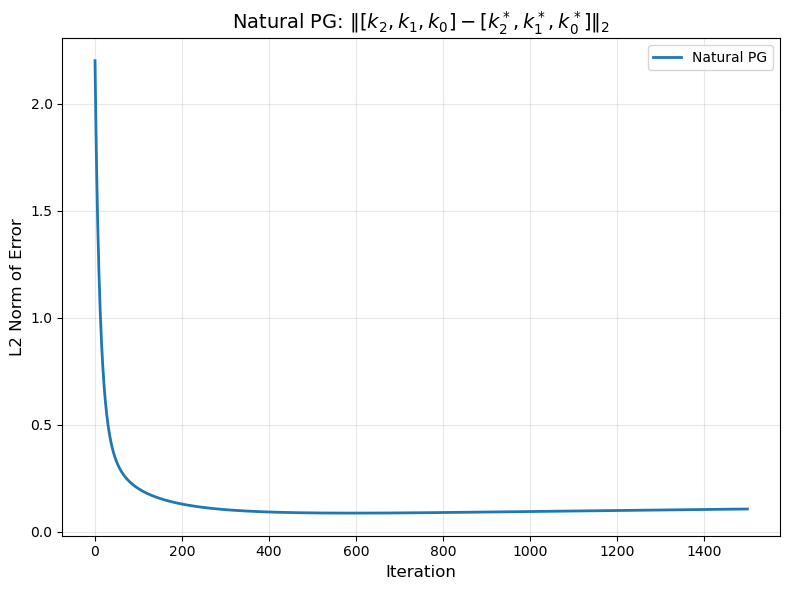

In [12]:
# Plot L2 norm of k error for Natural PG only
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# True k
k_true = np.array([k2, k1, k0])

# Compute L2 norm of k error
k_error_na = np.linalg.norm(k_history_na - k_true, axis=1)

# Plot
ax.plot(k_error_na, label='Natural PG', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('L2 Norm of Error', fontsize=12)
ax.set_title(r'Natural PG: $\|[k_2, k_1, k_0] - [k_2^*, k_1^*, k_0^*]\|_2$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

# ============================================================
# Closed-form PhiBE optimum for each dt (direct substitution)
# Assumption:
#   dS_t = (A S_t + B a_t) dt + sigma dW_t
# and we use the discretized PhiBE coefficients:
#   S_{n+1} = S_n + dt (A_t S_n + B_t a_n) + noise
# where Var(noise)/dt = sigma_t2
#
# This version directly plugs (A_t, B_t, sigma_t2) into the
# known closed-form solution of the regularized LQR HJB.
#
# IMPORTANT CONVENTION:
#   Returned "k2, k1, k0" satisfy
#       V(s) = 0.5 * k2 * s^2 + k1 * s + k0
# which matches your analytical formula in the paper/screenshot.
# ============================================================
def phibe_closed_form_optimum(
    beta,
    dt,
    A=-1.0,
    B=1.0,
    sigma=2,
    M=1.0,
    N=1.0,
    lambda_reg=0.1,
):
    # --------------------------------------------------------
    # Discretized PhiBE coefficients
    # --------------------------------------------------------
    A_t = (np.exp(A * dt) - 1.0) / dt

    if abs(A) < 1e-12:
        B_t = B
        # limit as A -> 0
        sigma_t2 = sigma**2
    else:
        B_t = B * (np.exp(A * dt) - 1.0) / (A * dt)
        sigma_t2 = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A * dt)

    if abs(B_t) < 1e-14:
        raise ValueError("B_t is too close to zero, closed-form control coefficient is undefined.")
    if N <= 0:
        raise ValueError("N must be positive.")
    if lambda_reg <= 0:
        raise ValueError("lambda_reg must be positive.")
    if beta <= 0:
        raise ValueError("beta must be positive.")

    # --------------------------------------------------------
    # Closed-form value function coefficients
    # V(s) = 0.5 * k2 * s^2 + k1 * s + k0
    # obtained by direct substitution:
    #   A -> A_t, B -> B_t, sigma^2 -> sigma_t2
    # --------------------------------------------------------
    radicand = (A_t - 0.5 * beta) ** 2 + (M * B_t**2) / N
    sqrt_term = np.sqrt(radicand)

    k2_star = (N / (B_t**2)) * (0.5 * beta - A_t - sqrt_term)
    k1_star = 0.0
    k0_star = -(lambda_reg / (2.0 * beta)) * np.log(N / (2.0 * np.pi * lambda_reg)) \
              + (sigma_t2 / (2.0 * beta)) * k2_star

    # --------------------------------------------------------
    # Optimal Gaussian policy:
    # pi*(a|s) = N( (B_t/N) * (k2 s + k1), lambda_reg / N )
    # so in the parameterization a|s ~ N(omega1*s + omega2, omega3^2):
    # --------------------------------------------------------
    w1_star = (B_t / N) * k2_star
    w2_star = (B_t / N) * k1_star
    w3_star = np.sqrt(lambda_reg / N)

    return {
        "omega1": w1_star,
        "omega2": w2_star,
        "omega3": w3_star,
        "k2": k2_star,
        "k1": k1_star,
        "k0": k0_star,
        "A_t": A_t,
        "B_t": B_t,
        "sigma_t2": sigma_t2,
    }

### fix beta, sweep dt

In [ ]:
# ============================================================
# Sweep T_f = dt from 1e-2 to 1, run NPG for each dt, plot 10 figures
# ============================================================

dt_grid = np.logspace(-3, 0, 10)   
k_true = np.array([k2, k1, k0])    
all_runs = []

for dt_val in dt_grid:
    print("=" * 70)
    print(f"Running NPG with T_f = dt = {dt_val:.5f}")

    # run NPG
    npg = NaturalPG_on_policy(
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
        beta=beta,
        learning_rate=eta_natural,
        T=dt_val,
        dt=dt_val,
        n_traj=N_traj,
        max_iter=1500, 
    )

    final_omega, omega_history_npg, grad_history_npg, _, _, _ = npg.run_single_trial(
        omega_init=omega_init,
        verbose=False
    )

    # find valid iterations
    valid_mask = np.any(omega_history_npg != 0, axis=1)
    iter_na = np.sum(valid_mask)

    omega_hist_valid = omega_history_npg[:iter_na, :]

    # map omega -> (k2, k1, k0)
    k_history_na = np.zeros((iter_na, 3))
    for i in range(iter_na):
        omega = omega_hist_valid[i, :]
        k_history_na[i, :] = [
            k_2_o_func(omega[0], omega[1], omega[2]),
            k_1_o_func(omega[0], omega[1], omega[2]),
            k_0_o_func(omega[0], omega[1], omega[2]),
        ]

    # compute error
    k_error_na = np.linalg.norm(k_history_na - k_true, axis=1)

    # save results
    all_runs.append({
        "dt": dt_val,
        "T_f": dt_val,
        "final_omega": final_omega,
        "omega_history": omega_history_npg,
        "grad_history": grad_history_npg,
        "k_history": k_history_na,
        "k_error": k_error_na,
    })

    # plot one figure for this dt
    plt.figure(figsize=(8, 6))
    plt.plot(k_error_na, linewidth=2, label="Natural PG")
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("L2 Norm of Error", fontsize=12)
    plt.title(rf"Natural PG: $T_f = dt = {dt_val:.3g}$", fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Running NPG with T_f = dt = 0.00100


C:\Users\chenbt\Downloads\LQR code\LQR code\python code\on_policy_func.py:17: RuntimeWarning: invalid value encountered in log
  return -0.5 * np.log(2 * np.pi) - np.log(std) - 0.5 * ((a - mean) / std) ** 2


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Given omega = (omega1, omega2, omega3), compute the
# dt-dependent PhiBE value coefficients:
#     V(s) = 0.5 * k2 * s^2 + k1 * s + k0
# by direct substitution A->A_t, B->B_t, sigma^2->sigma_t2
# ============================================================
def phibe_value_coeffs_from_omega(
    omega1,
    omega2,
    omega3,
    beta,
    dt,
    A=-1.0,
    B=1.0,
    sigma=2,
    M=1.0,
    N=1.0,
    lambda_reg=0.1,
    include_diffusion=True,
):
    A_t = (np.exp(A * dt) - 1.0) / dt

    if abs(A) < 1e-12:
        B_t = B
        sigma_t2 = sigma**2
    else:
        B_t = B * (np.exp(A * dt) - 1.0) / (A * dt)
        sigma_t2 = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A * dt)

    # protect log(omega3) numerically
    omega3_safe = max(omega3, 1e-12)

    k2 = -(M + N * omega1**2) / (beta - 2.0 * (A_t + B_t * omega1))
    k1 = (B_t * omega2 * k2 - N * omega1 * omega2) / (beta - (A_t + B_t * omega1))

    entropy_term = lambda_reg * (
        0.5 * np.log(2.0 * np.pi) + np.log(omega3_safe) + 0.5
    )

    diffusion_term = 0.5 * sigma_t2 * k2 if include_diffusion else 0.0

    k0 = (
        -0.5 * N * (omega2**2 + omega3_safe**2)
        + entropy_term
        + B_t * omega2 * k1
        + diffusion_term
    ) / beta

    return {
        "k2": k2,
        "k1": k1,
        "k0": k0,
        "A_t": A_t,
        "B_t": B_t,
        "sigma_t2": sigma_t2,
    }


# ============================================================
# Sweep T_f = dt from 1e-2 to 1
# For each dt:
#   (1) run NPG
#   (2) compute dt-dependent PhiBE optimum
#   (3) compare NPG value coefficients to PhiBE optimum
# ============================================================

# dt_grid = np.logspace(-2, 0, 15) 
# all_runs = []

# for dt_val in dt_grid:
#     print("=" * 70)
#     print(f"Running NPG with T_f = dt = {dt_val:.5f}")

#     # --------------------------------------------------------
#     # dt-dependent PhiBE optimum
#     # --------------------------------------------------------
#     phibe_ref = phibe_closed_form_optimum(
#         beta=beta,
#         dt=dt_val,
#         A=A,
#         B=B,
#         sigma=sigma,
#         M=M,
#         N=N,
#         lambda_reg=lambda_reg,
#     )

#     k_true_phibe = np.array([
#         phibe_ref["k2"],
#         phibe_ref["k1"],
#         phibe_ref["k0"],
#     ])

#     omega_true_phibe = np.array([
#         phibe_ref["omega1"],
#         phibe_ref["omega2"],
#         phibe_ref["omega3"],
#     ])

#     # --------------------------------------------------------
#     # run NPG
#     # --------------------------------------------------------
#     npg = NaturalPG_on_policy(
#         A=A,
#         B=B,
#         sigma=sigma,
#         M=M,
#         N=N,
#         lambda_reg=lambda_reg,
#         beta=beta,
#         learning_rate=eta_natural,
#         T=dt_val,
#         dt=dt_val,
#         n_traj=N_traj,
#         max_iter=500,
#     )

#     final_omega, omega_history_npg, grad_history_npg = npg.run_single_trial(
#         omega_init=omega_init,
#         verbose=False
#     )

#     # find valid iterations
#     valid_mask = np.any(omega_history_npg != 0, axis=1)
#     iter_na = np.sum(valid_mask)

#     omega_hist_valid = omega_history_npg[:iter_na, :]

#     # map omega -> (k2, k1, k0)
#     k_history_na = np.zeros((iter_na, 3))
#     for i in range(iter_na):
#         omega = omega_hist_valid[i, :]
#         k_history_na[i, :] = [
#             k_2_o_func(omega[0], omega[1], omega[2]),
#             k_1_o_func(omega[0], omega[1], omega[2]),
#             k_0_o_func(omega[0], omega[1], omega[2]),
#         ]

#     # --------------------------------------------------------
#     # compare NPG to dt-dependent PhiBE optimum
#     # --------------------------------------------------------
#     k_error_na = np.linalg.norm(k_history_na - k_true_phibe[None, :], axis=1)
#     omega_error_na = np.linalg.norm(omega_hist_valid - omega_true_phibe[None, :], axis=1)

#     # --------------------------------------------------------
#     # save results
#     # --------------------------------------------------------
#     all_runs.append({
#         "dt": dt_val,
#         "T_f": dt_val,
#         "phibe_ref": phibe_ref,
#         "final_omega": final_omega,
#         "omega_history": omega_history_npg,
#         "grad_history": grad_history_npg,
#         "k_history": k_history_na,
#         "k_error": k_error_na,
#         "omega_error": omega_error_na,
#     })

#     # --------------------------------------------------------
#     # plot value-function error
#     # --------------------------------------------------------
#     plt.figure(figsize=(8, 6))
#     plt.plot(k_error_na, linewidth=2, label="NPG vs PhiBE optimum")
#     plt.xlabel("Iteration", fontsize=12)
#     plt.ylabel("L2 error of (k2, k1, k0)", fontsize=12)
#     plt.title(rf"$T_f = dt = {dt_val:.3g}$", fontsize=14)
#     plt.legend(fontsize=10)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

Running final-iterate comparison for T_f = dt = 0.01000
Running final-iterate comparison for T_f = dt = 0.02371
Running final-iterate comparison for T_f = dt = 0.05623
Running final-iterate comparison for T_f = dt = 0.13335
Running final-iterate comparison for T_f = dt = 0.31623


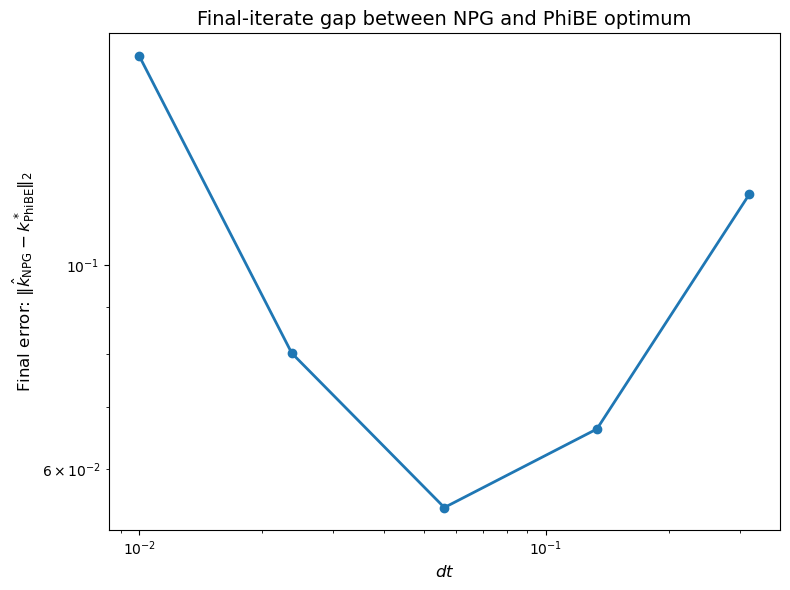

In [9]:
# ============================================================
# Sweep dt, compare FINAL NPG solution with dt-dependent
# PhiBE optimal solution
# ============================================================

def value_from_k(s, k):
    k2, k1, k0 = k
    return 0.5 * k2 * s**2 + k1 * s + k0

dt_grid = np.logspace(-2, -0.5, 5)  
rows = []
rows_iter = []

for dt_val in dt_grid:
    print("=" * 70)
    print(f"Running final-iterate comparison for T_f = dt = {dt_val:.5f}")

    # --------------------------------------------------------
    # PhiBE optimum for this dt
    # --------------------------------------------------------
    phibe_ref = phibe_closed_form_optimum(
        beta=beta,
        dt=dt_val,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
    )

    k_true_phibe = np.array([
        phibe_ref["k2"],
        phibe_ref["k1"],
        phibe_ref["k0"],
    ])

    omega_true_phibe = np.array([
        phibe_ref["omega1"],
        phibe_ref["omega2"],
        phibe_ref["omega3"],
    ])

    # --------------------------------------------------------
    # Run NPG
    # --------------------------------------------------------
    npg = NaturalPG_on_policy(
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
        beta=beta,
        learning_rate=eta_natural,
        T=dt_val,
        dt=dt_val,
        n_traj=5000,
        max_iter=1500,
    )

    final_omega, omega_history_npg, grad_history_npg, theta_diff_history, grad_diff_history, A_diff_history, value_diff_history, b_diff_history = npg.run_single_trial(
        omega_init=omega_init,
        verbose=False
    )

    # find valid iterations
    valid_mask = np.any(omega_history_npg != 0, axis=1)
    iter_na = np.sum(valid_mask)

    omega_hist_valid = omega_history_npg[:iter_na, :]
    grad_hist_valid = grad_history_npg[:iter_na, :]
    theta_diff_valid = theta_diff_history[:iter_na]
    grad_diff_valid = grad_diff_history[:iter_na]
    A_diff_valid = A_diff_history[:iter_na]
    value_diff_valid = value_diff_history[:iter_na]
    b_diff_valid = b_diff_history[:iter_na]

    # --------------------------------------------------------
    # Store iteration-wise theta/grad diff
    # --------------------------------------------------------
    for i in range(iter_na):
        rows_iter.append({
            "dt": dt_val,
            "T_f": dt_val,
            "iter": i + 1,
            "theta_diff_l2": theta_diff_valid[i],
            "grad_diff_l2": grad_diff_valid[i],
            "A_diff_l2": A_diff_valid[i],
            "value_diff_l2": value_diff_valid[i],
            "b_diff_l2": b_diff_valid[i],
        })


    # map omega -> (k2, k1, k0)
    k_history_na = np.zeros((iter_na, 3))
    for i in range(iter_na):
        omega = omega_hist_valid[i, :]
        k_history_na[i, :] = [
            k_2_o_func(omega[0], omega[1], omega[2]),
            k_1_o_func(omega[0], omega[1], omega[2]),
            k_0_o_func(omega[0], omega[1], omega[2]),
        ]

    # --------------------------------------------------------
    # Map final NPG omega to dt-dependent PhiBE value coeffs
    # --------------------------------------------------------
    omega_final = omega_hist_valid[-1, :]
    # coeffs_final = phibe_value_coeffs_from_omega(
    #     omega1=omega_final[0],
    #     omega2=omega_final[1],
    #     omega3=omega_final[2],
    #     beta=beta,
    #     dt=dt_val,
    #     A=A,
    #     B=B,
    #     sigma=sigma,
    #     M=M,
    #     N=N,
    #     lambda_reg=lambda_reg,
    #     include_diffusion=True,
    # )

    # k_true_phibe = np.array([
    #     coeffs_final["k2"],
    #     coeffs_final["k1"],
    #     coeffs_final["k0"],
    # ])

    # --------------------------------------------------------
    # Errors at FINAL iteration
    # --------------------------------------------------------
    s_grid = np.linspace(-3.0, 3.0, 1000)

    k_final_npg = k_history_na[-1, :]
    #omega_final = omega_hist_valid[-1, :]
    V_npg_grid = value_from_k(s_grid, k_final_npg)
    V_phibe_grid = value_from_k(s_grid, k_true_phibe)
    V_diff_grid = V_npg_grid - V_phibe_grid

    # --------------------------------------------------------
    # Errors on value function
    # --------------------------------------------------------
    value_rmse_final = np.sqrt(np.mean(V_diff_grid**2))
    value_mae_final = np.mean(np.abs(V_diff_grid))
    value_max_final = np.max(np.abs(V_diff_grid))
    k_error_final = np.linalg.norm(k_final_npg - k_true_phibe)
    omega_error_final = np.linalg.norm(omega_final - omega_true_phibe)

    rows.append({
        "dt": dt_val,
        "T_f": dt_val,
        "omega1_final": omega_final[0],
        "omega2_final": omega_final[1],
        "omega3_final": omega_final[2],
        "omega1_phibe": omega_true_phibe[0],
        "omega2_phibe": omega_true_phibe[1],
        "omega3_phibe": omega_true_phibe[2],
        "k2_final": k_final_npg[0],
        "k1_final": k_final_npg[1],
        "k0_final": k_final_npg[2],
        "k2_phibe": k_true_phibe[0],
        "k1_phibe": k_true_phibe[1],
        "k0_phibe": k_true_phibe[2],
        "k_error_final": k_error_final,
        "omega_error_final": omega_error_final,
        "value_rmse_final": value_rmse_final,
        "value_mae_final": value_mae_final,
        "value_max_final": value_max_final,
    })


#df_final = pd.DataFrame(rows)
df_iter = pd.DataFrame(rows_iter)

# ============================================================
# Make dataframe
# ============================================================
df_final_compare = pd.DataFrame(rows).sort_values("dt").reset_index(drop=True)
#display(df_final_compare)

# ============================================================
# Plot: final value-function error vs dt
# ============================================================
plt.figure(figsize=(8, 6))
plt.loglog(df_final_compare["dt"], df_final_compare["k_error_final"], marker="o", linewidth=2)
plt.xlabel(r"$dt$", fontsize=12)
plt.ylabel(r"Final error: $\|\hat{k}_{\mathrm{NPG}} - k^*_{\mathrm{PhiBE}}\|_2$", fontsize=12)
plt.title("Final-iterate gap between NPG and PhiBE optimum", fontsize=14)
plt.tight_layout()
plt.show()

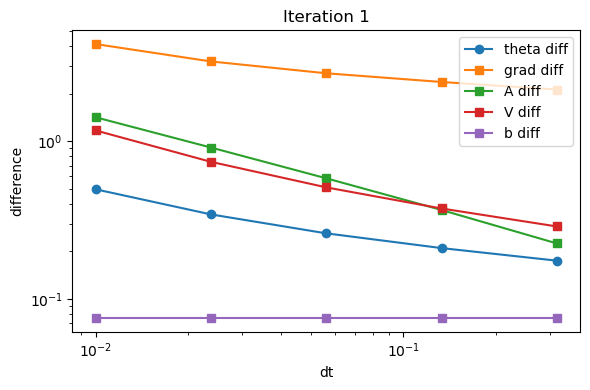

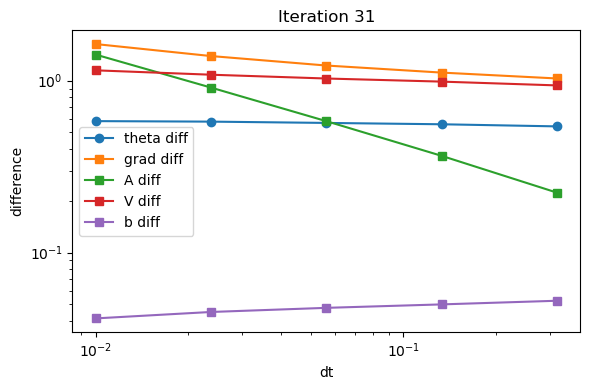

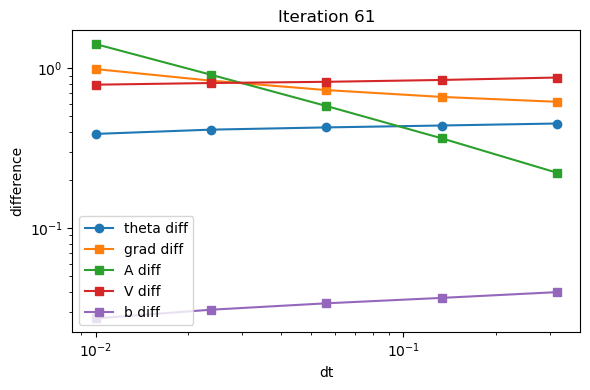

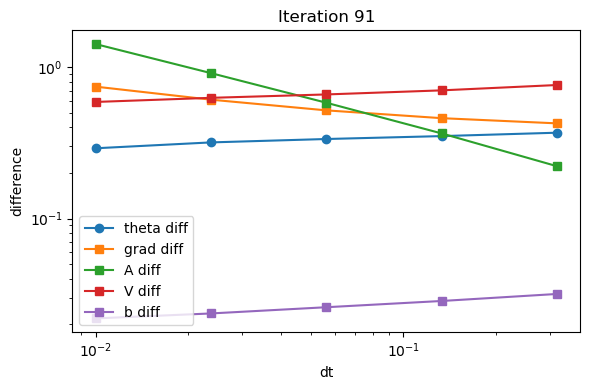

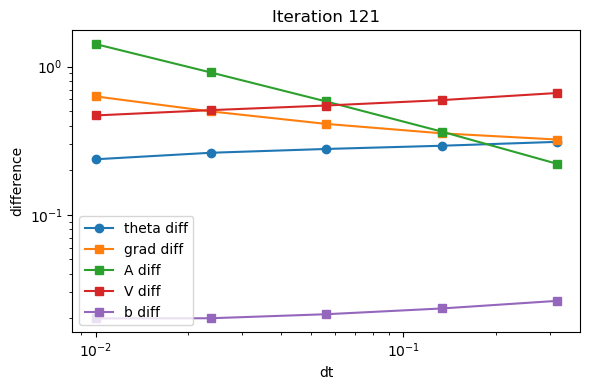

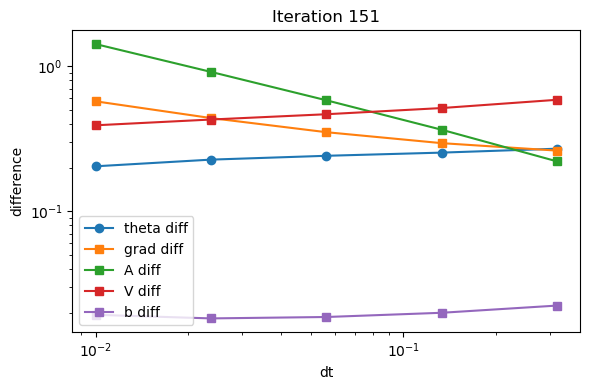

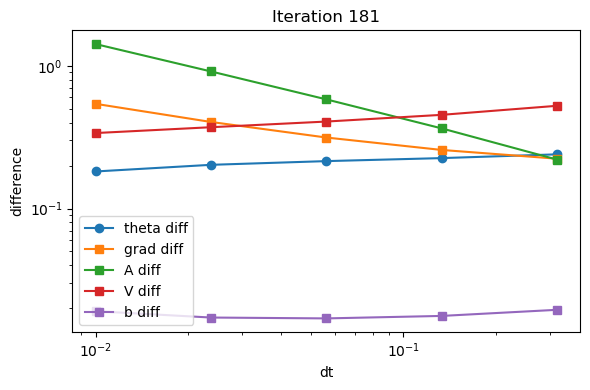

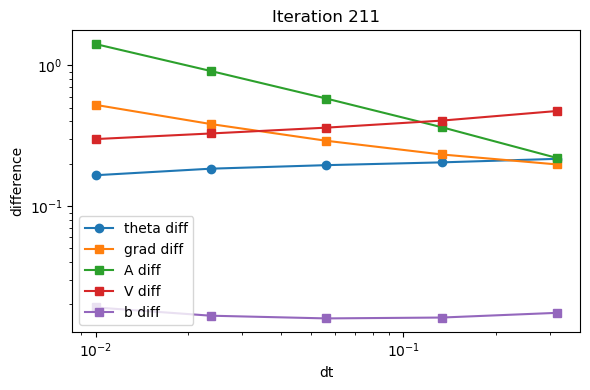

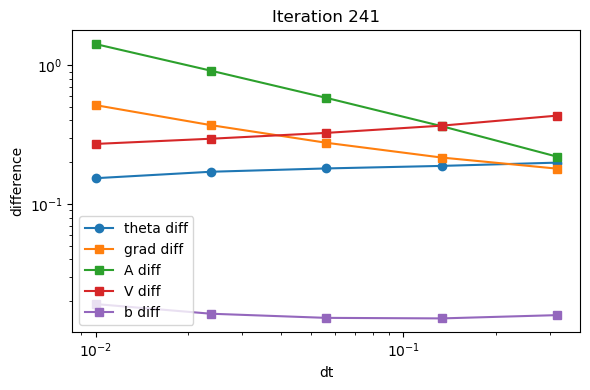

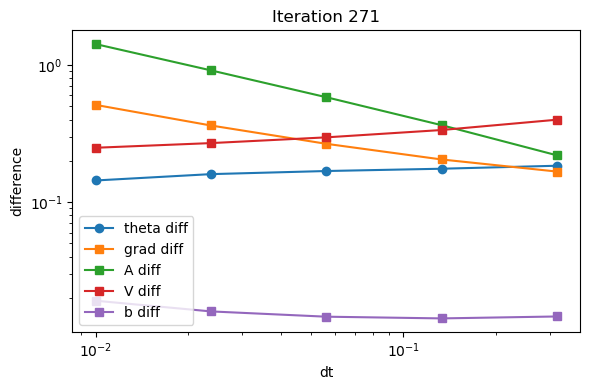

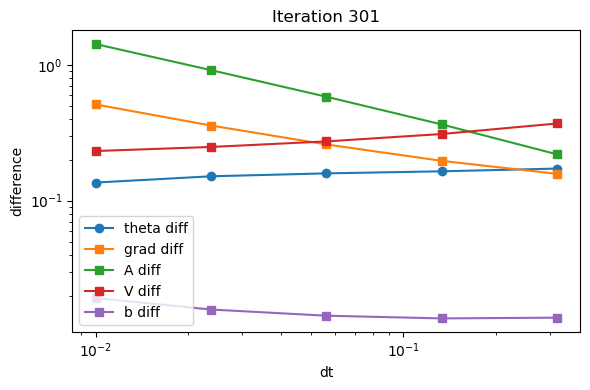

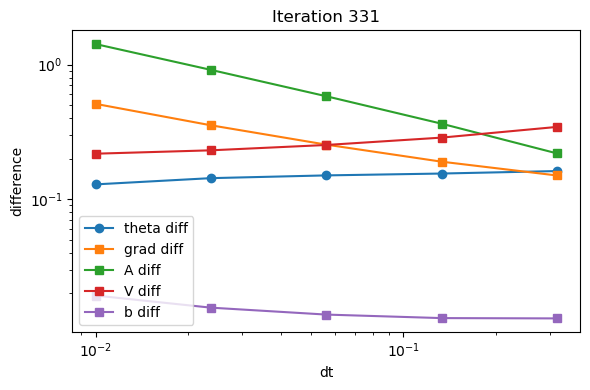

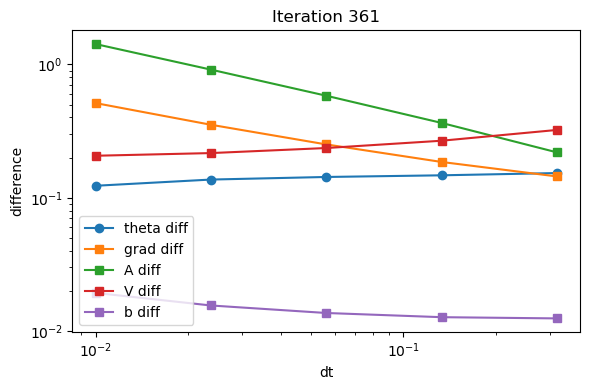

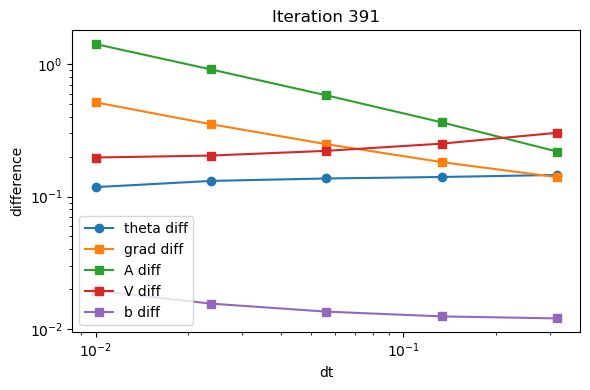

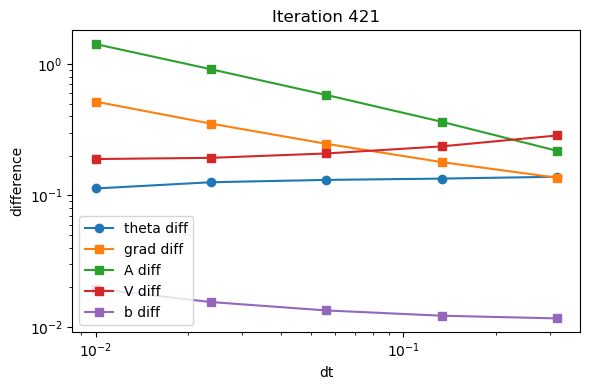

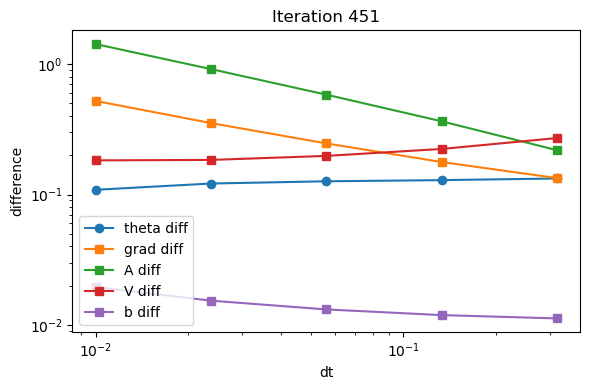

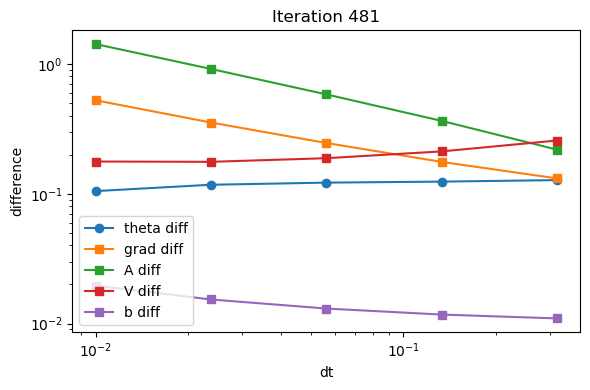

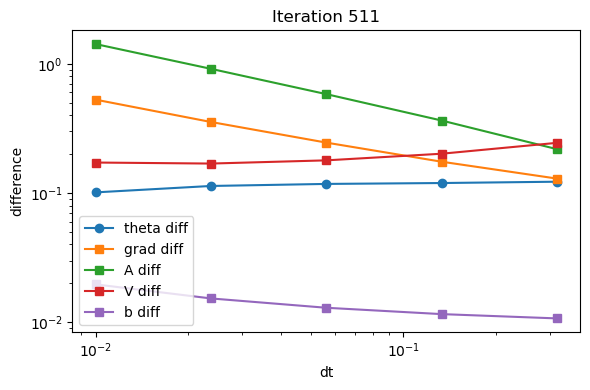

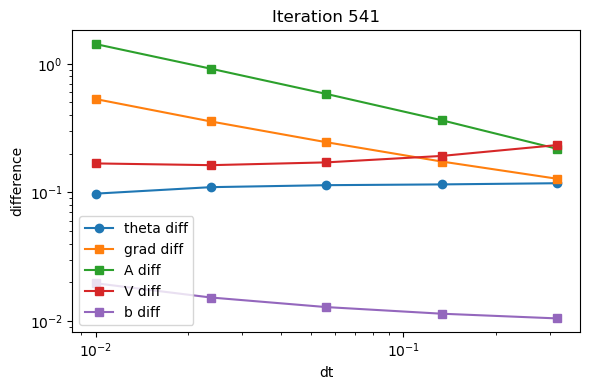

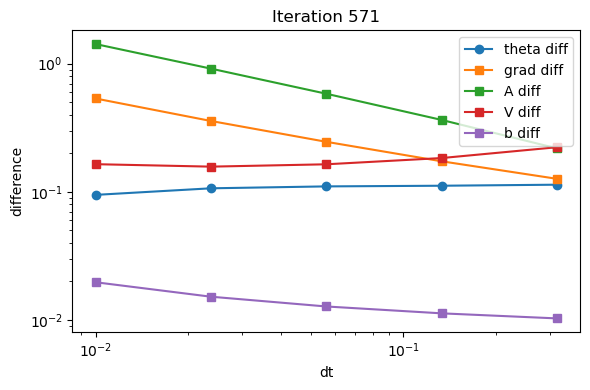

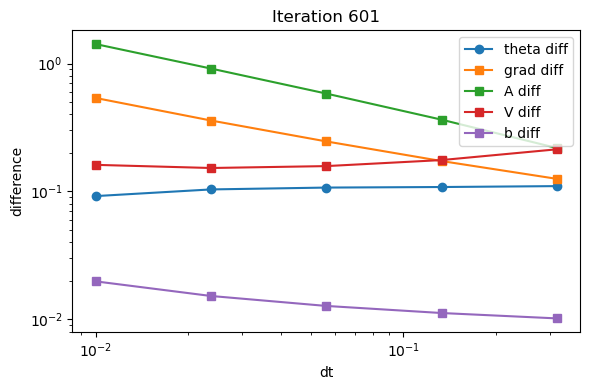

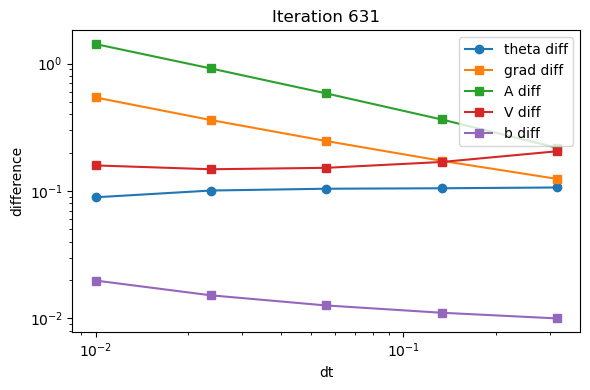

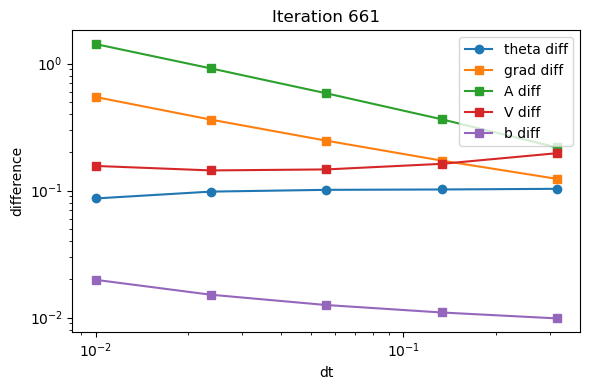

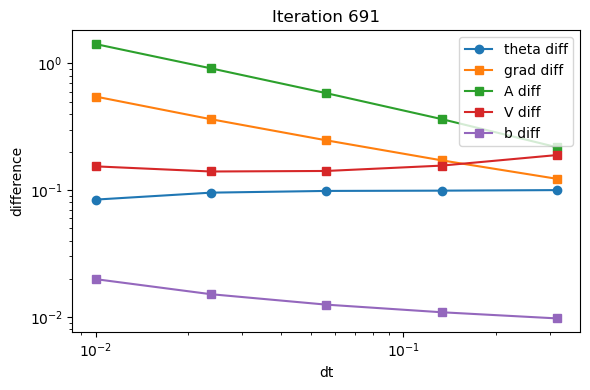

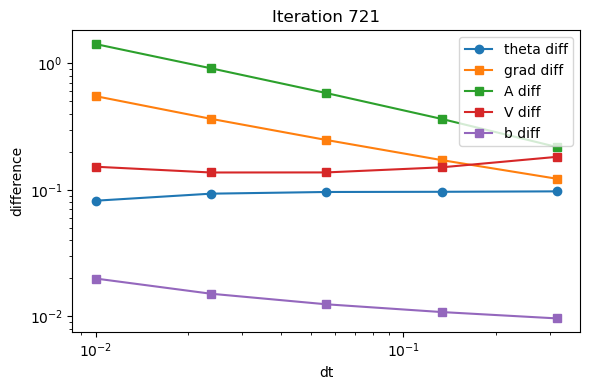

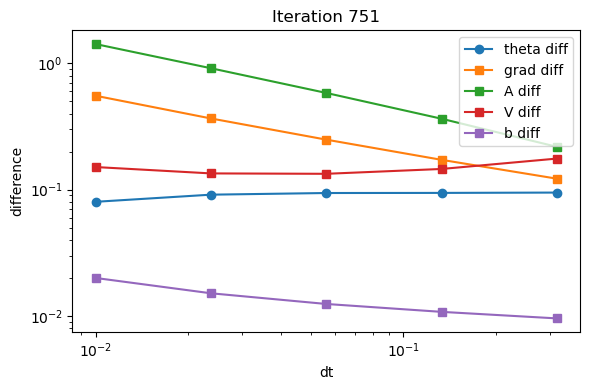

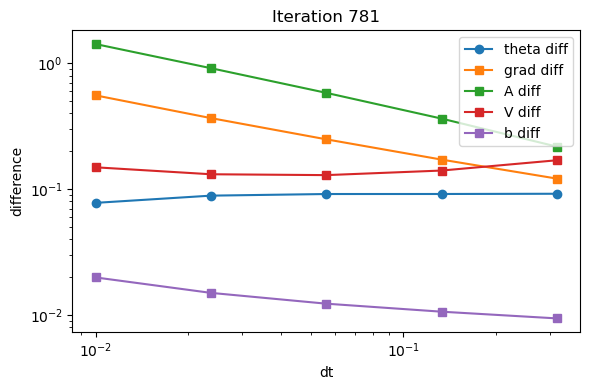

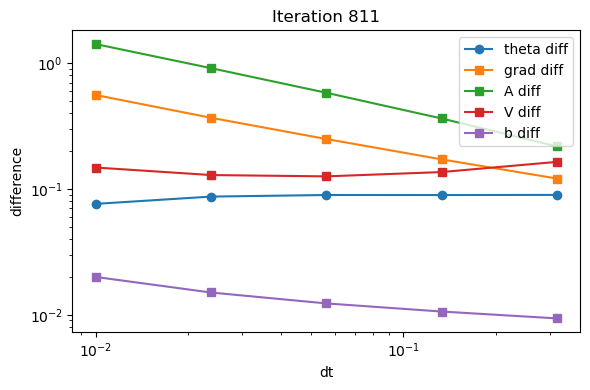

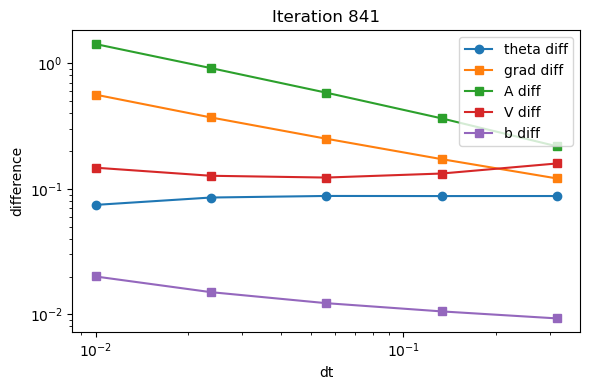

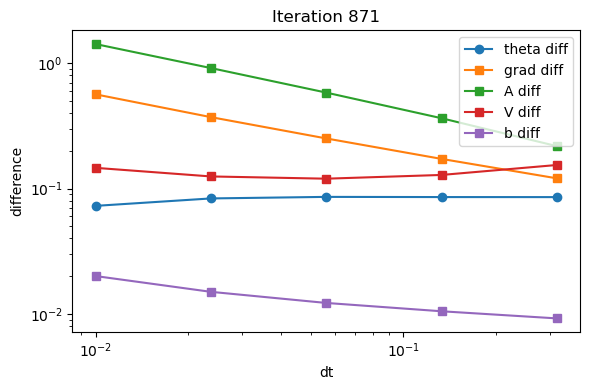

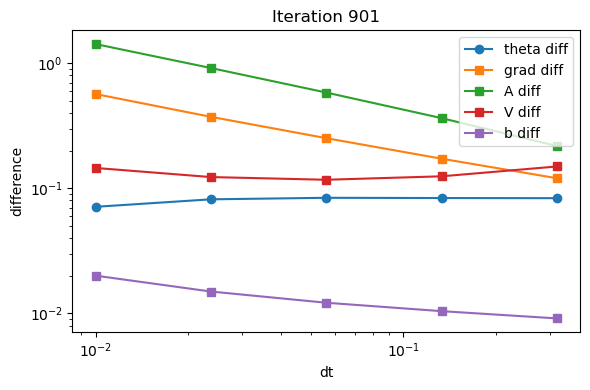

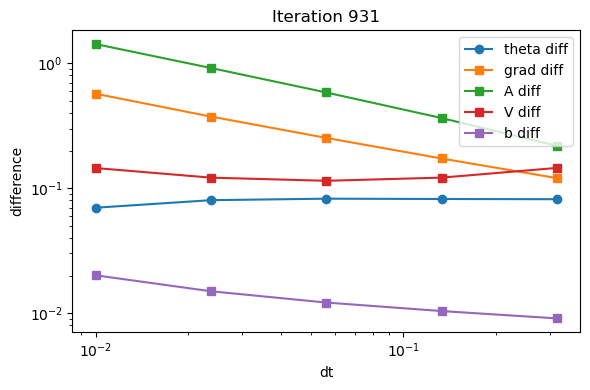

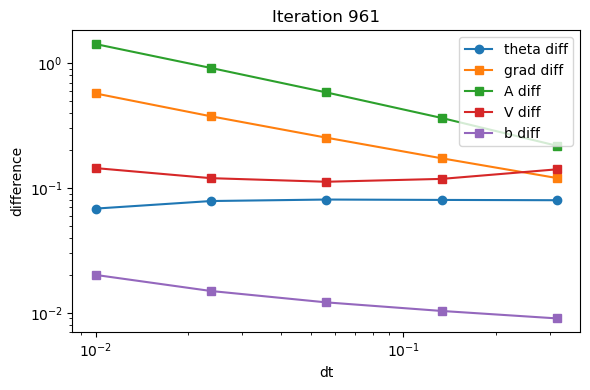

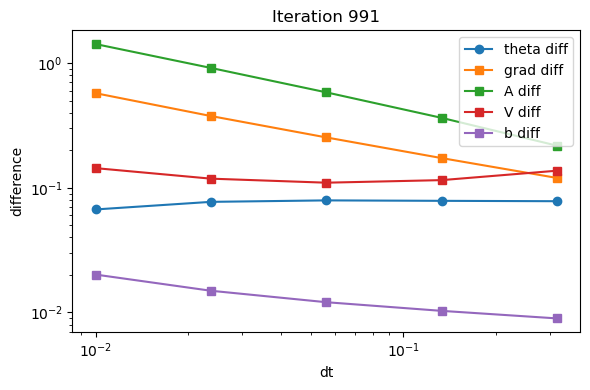

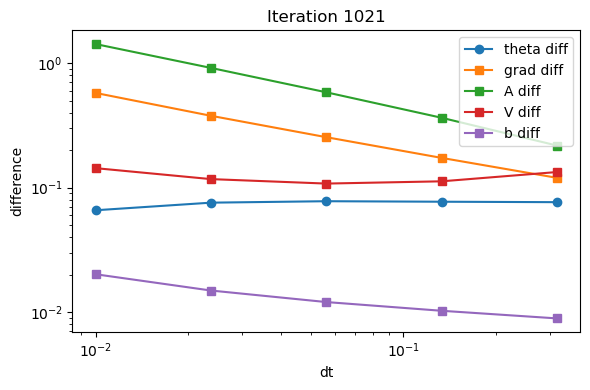

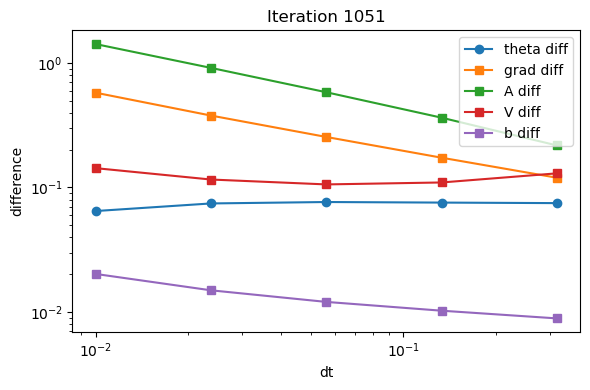

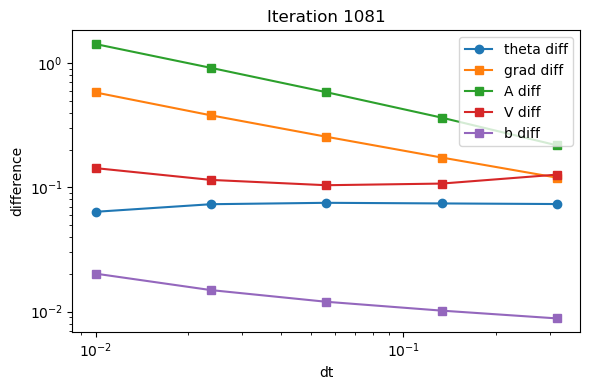

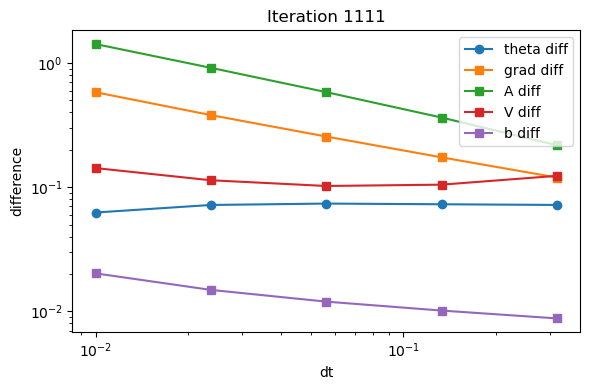

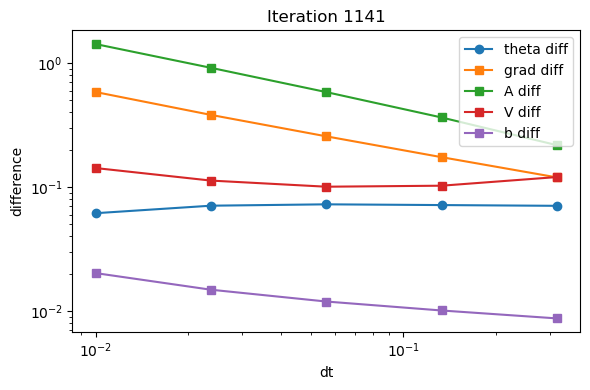

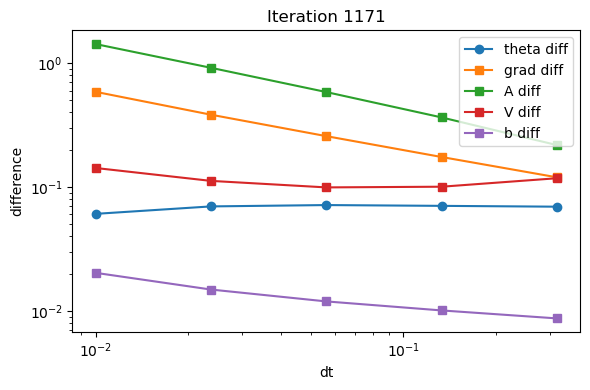

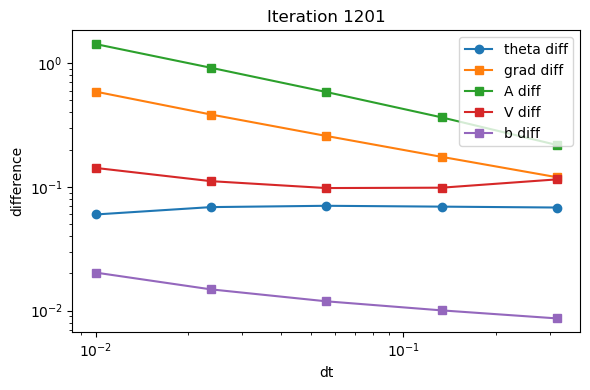

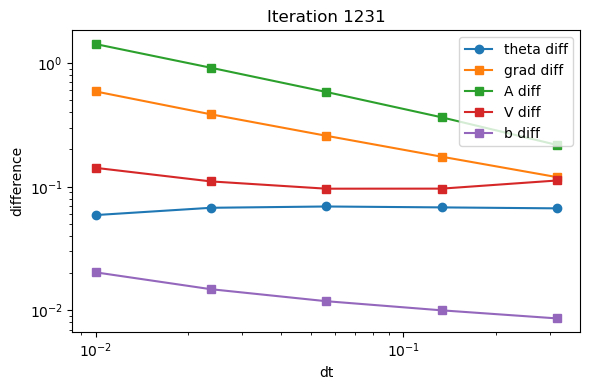

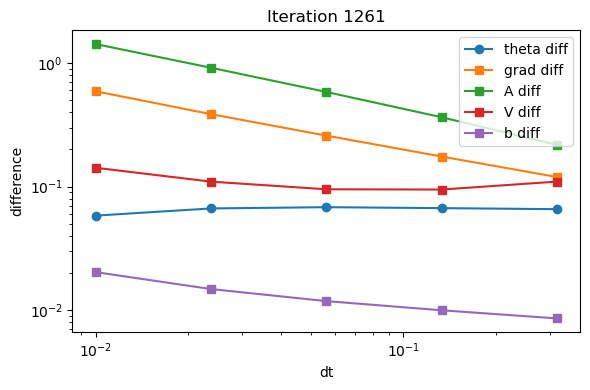

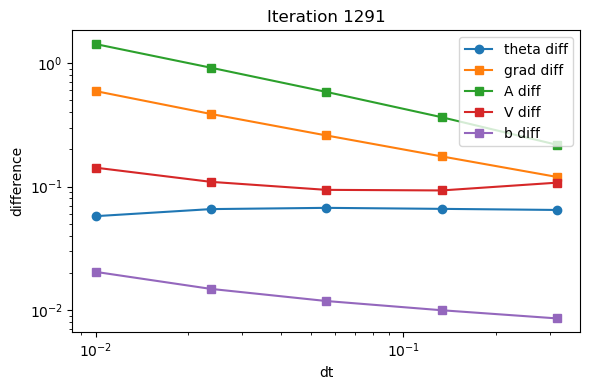

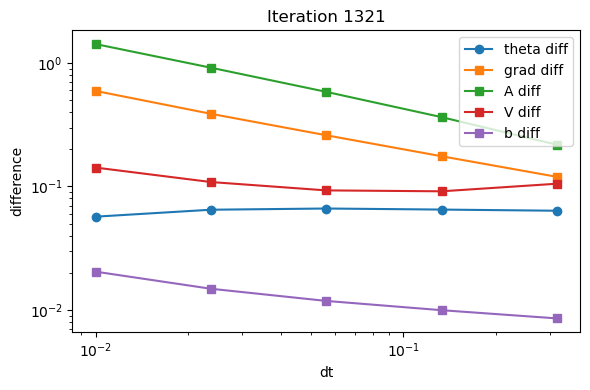

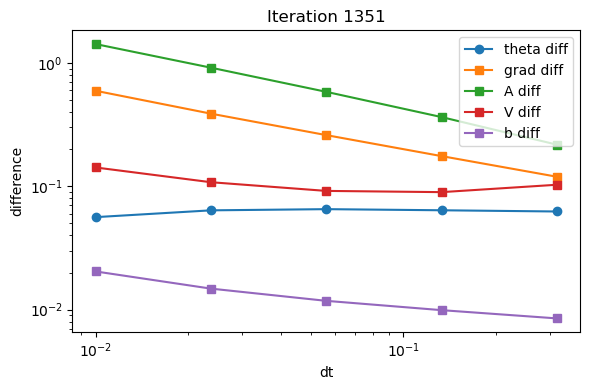

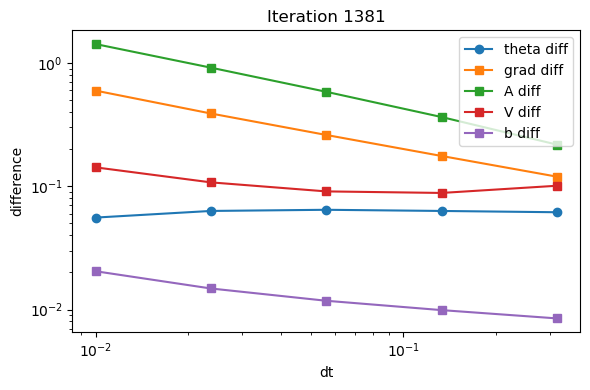

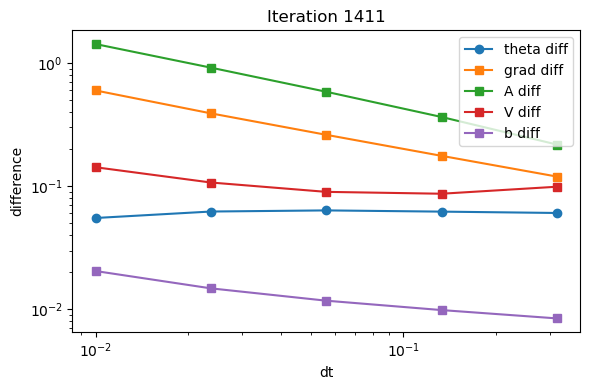

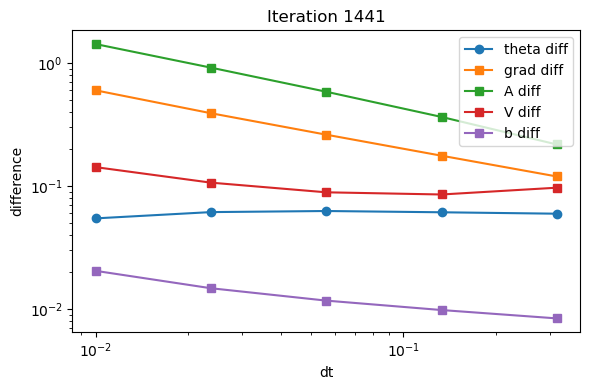

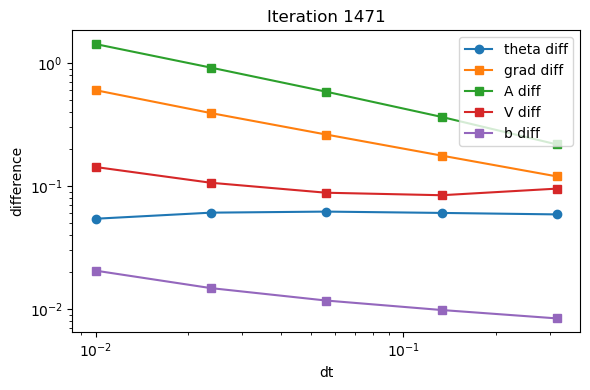

In [11]:
# iter_list = [1, 20, 50, 100, 300, 500, 800, 1000, 1200, 1500]
# iter_list = list(range(10, 1501, 10))
# for k in iter_list:
#     df_k = df_iter[df_iter["iter"] == k].sort_values("dt")

#     plt.figure(figsize=(6, 4))
#     plt.plot(df_k["dt"], df_k["theta_diff_l2"], marker="o", label=r"$\|\theta-\theta_\Phi\|_2$")
#     plt.plot(df_k["dt"], df_k["grad_diff_l2"], marker="s", label=r"$\|g-g_\Phi\|_2$")
#     plt.plot(df_k["dt"], df_k["A_diff_l2"], marker="s", label=r"$\|A-A_\Phi\|_2$")
#     plt.xscale("log")
#     plt.yscale("log")
#     plt.xlabel("dt")
#     plt.ylabel("difference")
#     plt.title(f"Iteration {k}")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#all_iters = sorted(df_iter["iter"].unique())
all_iters = list(range(1, 1501, 30))
for k in all_iters:
    df_k = df_iter[df_iter["iter"] == k].sort_values("dt")

    plt.figure(figsize=(6, 4))
    plt.plot(df_k["dt"], df_k["theta_diff_l2"], marker="o", label="theta diff")
    plt.plot(df_k["dt"], df_k["grad_diff_l2"], marker="s", label="grad diff")
    plt.plot(df_k["dt"], df_k["A_diff_l2"], marker="s", label="A diff")
    plt.plot(df_k["dt"], df_k["value_diff_l2"], marker="s", label="V diff")
    plt.plot(df_k["dt"], df_k["b_diff_l2"], marker="s", label="b diff")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("dt")
    plt.ylabel("difference")
    plt.title(f"Iteration {k}")
    plt.legend()
    plt.tight_layout()
    plt.show()

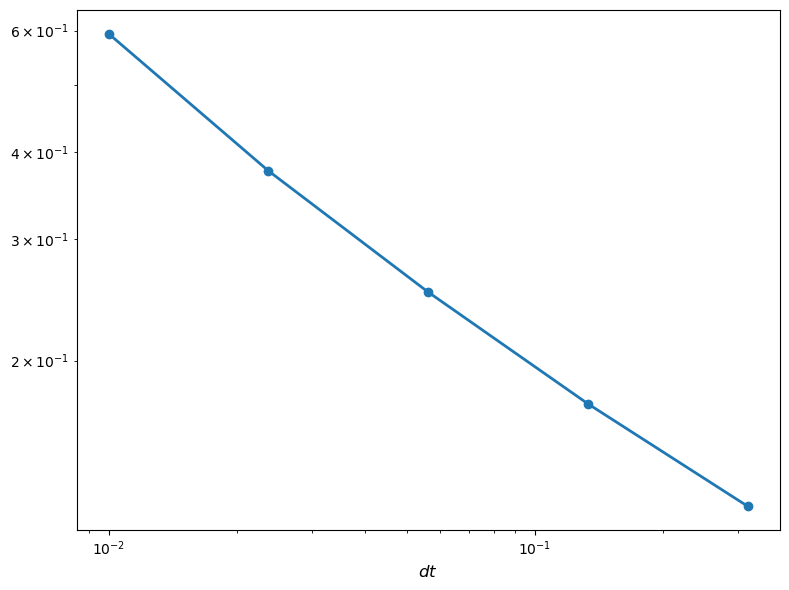

In [13]:
# ============================================================
plt.figure(figsize=(8, 6))
plt.loglog(df_final_compare["dt"], df_final_compare["omega_error_final"], marker="o", linewidth=2)
plt.xlabel(r"$dt$", fontsize=12)
plt.tight_layout()
plt.show()

#omega_true = np.array([true_ref["w1"], true_ref["w2"], true_ref["w3"]])

omega_npg = df_final_compare[["omega1_final", "omega2_final", "omega3_final"]].values

omega_phibe = df_final_compare[["omega1_phibe", "omega2_phibe", "omega3_phibe"]].values

# ------------------------------------------------------------
# Compute three L2 errors in k-space
# ------------------------------------------------------------
df_plot = df_final_compare.copy()

df_plot["err_npg_phibe"] = np.linalg.norm(omega_npg - omega_phibe, axis=1)
#df_plot["err_phibe_true"] = np.linalg.norm(omega_phibe - omega_true, axis=1)
#df_plot["err_npg_true"]  = np.linalg.norm(omega_npg - omega_true, axis=1)

# ------------------------------------------------------------
# Plot all three on the same figure
# ------------------------------------------------------------
# plt.figure(figsize=(8, 6))

# plt.loglog(
#     df_plot["dt"], df_plot["err_npg_phibe"],
#     marker="o", linewidth=2, label="NPG vs PhiBE"
# )
# plt.loglog(
#     df_plot["dt"], df_plot["err_phibe_true"],
#     marker="s", linewidth=2, label="PhiBE vs True"
# )
# plt.loglog(
#     df_plot["dt"], df_plot["err_npg_true"],
#     marker="^", linewidth=2, label="NPG vs True"
# )

# plt.xlabel(r"$dt$", fontsize=12)
# plt.ylabel(r"$L_2$ error in $omega$", fontsize=12)
# plt.title("Three errors vs dt", fontsize=14)
# plt.legend(frameon=False)
# plt.tight_layout()
# plt.show()

slope = -0.4544, intercept = -2.6534


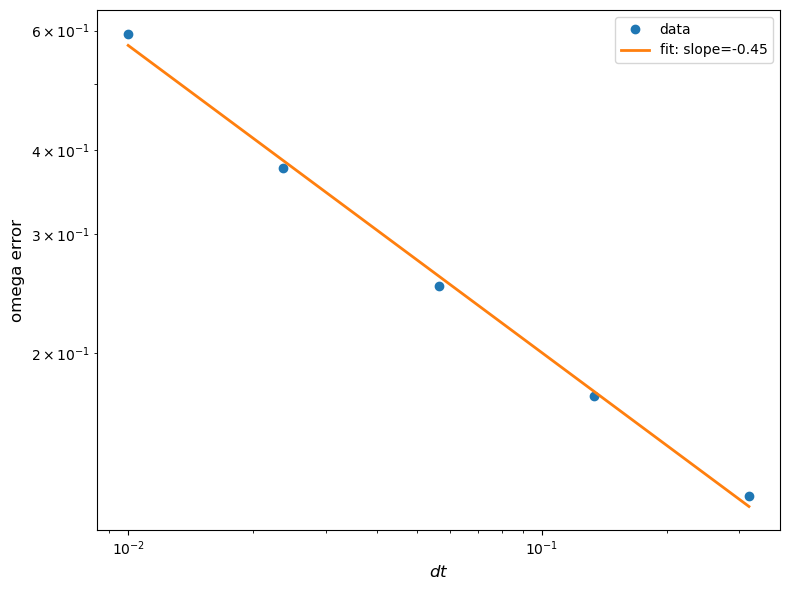

In [21]:
x = df_final_compare["dt"].values
y = df_final_compare["omega_error_final"].values

# ------------------------------------------------------------
# log-log 拟合
# ------------------------------------------------------------
logx = np.log(x)
logy = np.log(y)

coef = np.polyfit(logx, logy, 1)   # [slope, intercept]
slope, intercept = coef
print(f"slope = {slope:.4f}, intercept = {intercept:.4f}")

# 拟合曲线
x_fit = np.linspace(min(x), max(x), 200)
y_fit = np.exp(intercept) * x_fit**slope

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.loglog(x, y, "o", label="data")
plt.loglog(x_fit, y_fit, "-", linewidth=2,
           label=fr"fit: slope={slope:.2f}")

plt.xlabel(r"$dt$", fontsize=12)
plt.ylabel("omega error", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

Estimated log-log slope = 0.137834
Estimated intercept     = -1.828765


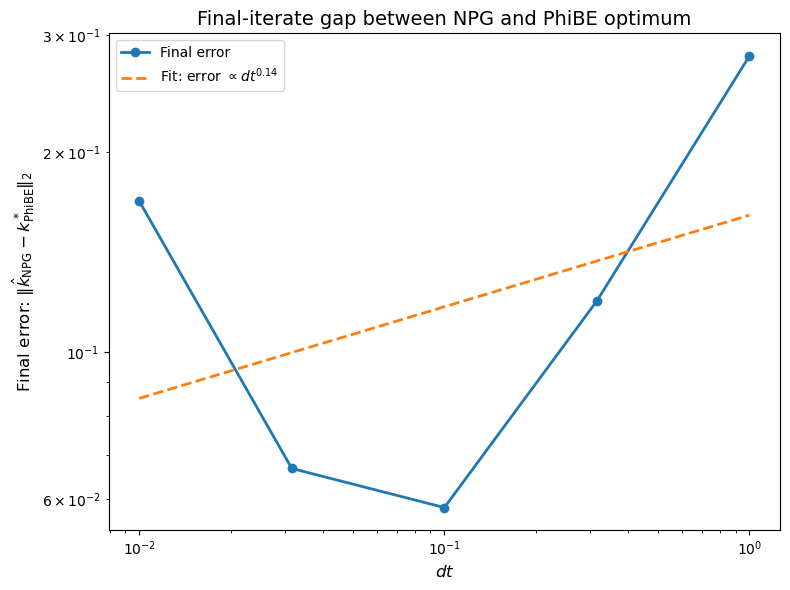

In [15]:
# ============================================================
# Prepare positive data only
# ============================================================
df_plot = df_final_compare.copy()
df_plot = df_plot[(df_plot["dt"] > 0) & (df_plot["k_error_final"] > 0)].copy()
df_plot = df_plot.sort_values("dt").reset_index(drop=True)

x = df_plot["dt"].values
y = df_plot["k_error_final"].values

# log-transform
logx = np.log(x)
logy = np.log(y)

# ============================================================
# Estimate global slope on log-log scale
# log(y) = slope * log(x) + intercept
# ============================================================
slope, intercept = np.polyfit(logx, logy, 1)

print(f"Estimated log-log slope = {slope:.6f}")
print(f"Estimated intercept     = {intercept:.6f}")

# fitted curve in original scale
y_fit = np.exp(intercept) * x**slope

# ============================================================
# Plot original log-log curve + fitted line
# ============================================================
plt.figure(figsize=(8, 6))
plt.loglog(x, y, marker="o", linewidth=2, label="Final error")
plt.loglog(
    x, y_fit, "--", linewidth=2,
    label=rf"Fit: error $\propto dt^{{{slope:.2f}}}$"
)
plt.xlabel(r"$dt$", fontsize=12)
plt.ylabel(r"Final error: $\|\hat{k}_{\mathrm{NPG}} - k^*_{\mathrm{PhiBE}}\|_2$", fontsize=12)
plt.title("Final-iterate gap between NPG and PhiBE optimum", fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

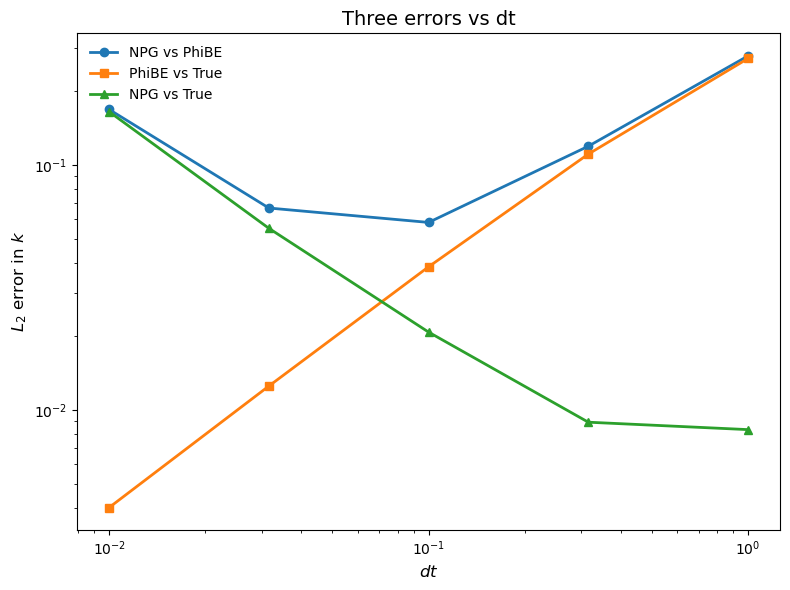

In [17]:
# ============================================================
# Three errors on the same plot:
# (1) NPG vs PhiBE
# (2) PhiBE vs True
# (3) NPG vs True
# ============================================================

K_true = np.array([k2, k1, k0])

# NPG final K
K_npg = df_final_compare[["k2_final", "k1_final", "k0_final"]].values

# PhiBE K
K_phibe = df_final_compare[["k2_phibe", "k1_phibe", "k0_phibe"]].values

# ------------------------------------------------------------
# Compute three L2 errors in k-space
# ------------------------------------------------------------
df_plot = df_final_compare.copy()

df_plot["err_npg_phibe"] = np.linalg.norm(K_npg - K_phibe, axis=1)
df_plot["err_phibe_true"] = np.linalg.norm(K_phibe - K_true, axis=1)
df_plot["err_npg_true"]  = np.linalg.norm(K_npg - K_true, axis=1)

# ------------------------------------------------------------
# Plot all three on the same figure
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.loglog(
    df_plot["dt"], df_plot["err_npg_phibe"],
    marker="o", linewidth=2, label="NPG vs PhiBE"
)
plt.loglog(
    df_plot["dt"], df_plot["err_phibe_true"],
    marker="s", linewidth=2, label="PhiBE vs True"
)
plt.loglog(
    df_plot["dt"], df_plot["err_npg_true"],
    marker="^", linewidth=2, label="NPG vs True"
)

plt.xlabel(r"$dt$", fontsize=12)
plt.ylabel(r"$L_2$ error in $k$", fontsize=12)
plt.title("Three errors vs dt", fontsize=14)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Continuous-time true solution
# Convention:
#   V(s) = 0.5 * k2 * s^2 + k1 * s + k0
# ============================================================
def true_solution_continuous_time(
    beta,
    A=-1.0,
    B=1.0,
    sigma=0.1,
    M=1.0,
    N=1.0,
    lambda_reg=0.1,
    include_diffusion=True,
):
    # k2*
    k2 = (N / B**2) * (
        0.5 * beta - A - np.sqrt((0.5 * beta - A)**2 + (B**2 * M) / N)
    )

    # symmetry
    k1 = 0.0

    # k0*
    k0 = -(lambda_reg / (2.0 * beta)) * np.log(N / (2.0 * np.pi * lambda_reg))

    if include_diffusion:
        k0 += (sigma**2 / (2.0 * beta)) * k2

    return {
        "k2": k2,
        "k1": k1,
        "k0": k0,
    }


# ============================================================
# Sweep dt and compare PhiBE optimum vs true solution
# IMPORTANT:
#   choose include_diffusion=True or False consistently
# ============================================================
include_diffusion = True   # change to False if you want no-diffusion benchmark

dt_grid = np.logspace(-4, 0, 30)   # from 1e-2 to 1
rows = []

# continuous-time true solution is dt-independent
true_ref = true_solution_continuous_time(
    beta=beta,
    A=A,
    B=B,
    sigma=sigma,
    M=M,
    N=N,
    lambda_reg=lambda_reg,
    include_diffusion=include_diffusion,
)

k_true = np.array([true_ref["k2"], true_ref["k1"], true_ref["k0"]])

for dt_val in dt_grid:
    phibe_ref = phibe_closed_form_optimum(
        beta=beta,
        dt=dt_val,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
    )

    k_phibe = np.array([phibe_ref["k2"], phibe_ref["k1"], phibe_ref["k0"]])

    diff = k_phibe - k_true

    rows.append({
        "dt": dt_val,

        "k2_phibe": k_phibe[0],
        "k1_phibe": k_phibe[1],
        "k0_phibe": k_phibe[2],

        "k2_true": k_true[0],
        "k1_true": k_true[1],
        "k0_true": k_true[2],

        "k2_diff": diff[0],
        "k1_diff": diff[1],
        "k0_diff": diff[2],

        "k2_diff_abs": abs(diff[0]),
        "k1_diff_abs": abs(diff[1]),
        "k0_diff_abs": abs(diff[2]),

        "k_error_l2": np.linalg.norm(diff, ord=2),
    })

df_compare_k = pd.DataFrame(rows).sort_values("dt").reset_index(drop=True)
#display(df_compare_k)

Estimated log-log slope = 0.974970


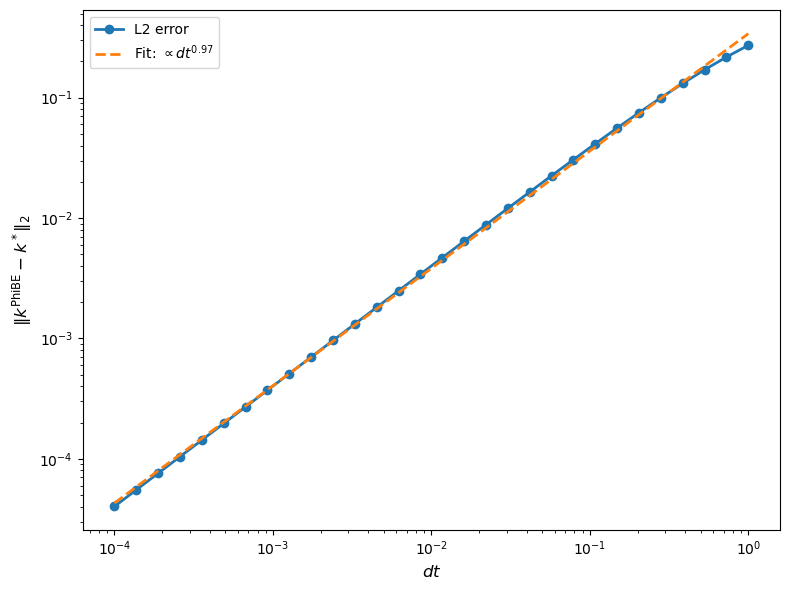

In [21]:
# ============================================================
# Plot absolute coordinate-wise differences
# ============================================================
# plt.figure(figsize=(8, 6))
# plt.loglog(df_compare_k["dt"], df_compare_k["k2_diff_abs"], marker="o", linewidth=2, label=r"$|k_2^{\mathrm{PhiBE}}-k_2^{*}|$")
# plt.loglog(df_compare_k["dt"], df_compare_k["k1_diff_abs"], marker="o", linewidth=2, label=r"$|k_1^{\mathrm{PhiBE}}-k_1^{*}|$")
# plt.loglog(df_compare_k["dt"], df_compare_k["k0_diff_abs"], marker="o", linewidth=2, label=r"$|k_0^{\mathrm{PhiBE}}-k_0^{*}|$")
# plt.xlabel(r"$dt$", fontsize=12)
# plt.ylabel("Absolute error", fontsize=12)
# plt.title("PhiBE optimum vs true solution (coordinate-wise)", fontsize=14)
# plt.legend(fontsize=10)
# plt.tight_layout()
# plt.show()

# ============================================================
# Estimate log-log slope for L2 error
# ============================================================
df_plot = df_compare_k[(df_compare_k["dt"] > 0) & (df_compare_k["k_error_l2"] > 0)].copy()

x = df_plot["dt"].values
y = df_plot["k_error_l2"].values

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)
y_fit = np.exp(intercept) * x**slope

print(f"Estimated log-log slope = {slope:.6f}")

plt.figure(figsize=(8, 6))
plt.loglog(x, y, marker="o", linewidth=2, label="L2 error")
plt.loglog(x, y_fit, "--", linewidth=2, label=rf"Fit: $\propto dt^{{{slope:.2f}}}$")
plt.xlabel(r"$dt$", fontsize=12)
plt.ylabel(r"$\|k^{\mathrm{PhiBE}}-k^*\|_2$", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [23]:
def true_solution_continuous_time(
    beta,
    A=-1.0,
    B=1.0,
    sigma=0.1,
    M=1.0,
    N=1.0,
    lambda_reg=0.1,
    include_diffusion=True,
):
    # k2*
    k2 = (N / B**2) * (
        0.5 * beta - A - np.sqrt((0.5 * beta - A)**2 + (B**2 * M) / N)
    )

    # symmetry
    k1 = 0.0

    # k0*
    k0 = -(lambda_reg / (2.0 * beta)) * np.log(N / (2.0 * np.pi * lambda_reg))

    if include_diffusion:
        k0 += (sigma**2 / (2.0 * beta)) * k2

    w1 = B * k2 / N
    w2 = B * k1 / N
    w3 = np.sqrt(lambda_reg / N)

    return {
        "w1": w1,
        "w2": w2,
        "w3": w3,
    }


# ============================================================
# Sweep dt and compare PhiBE optimum vs true solution
# IMPORTANT:
#   choose include_diffusion=True or False consistently
# ============================================================
include_diffusion = True   # change to False if you want no-diffusion benchmark

dt_grid = np.logspace(-5, -1, 50)   # from 1e-2 to 1
rows = []

# continuous-time true solution is dt-independent
true_ref = true_solution_continuous_time(
    beta=beta,
    A=A,
    B=B,
    sigma=0.1,
    M=M,
    N=N,
    lambda_reg=lambda_reg,
    include_diffusion=include_diffusion,
)

omega_true = np.array([true_ref["w1"], true_ref["w2"], true_ref["w3"]])

for dt_val in dt_grid:
    phibe_ref = phibe_closed_form_optimum(
        beta=beta,
        dt=dt_val,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
    )

    omega_phibe = np.array([phibe_ref["omega1"], phibe_ref["omega2"], phibe_ref["omega3"]])

    diff = omega_true - omega_phibe

    rows.append({
        "dt": dt_val,

        "omega_diff": diff[0],
        "omega_diff": diff[1],
        "omega_diff": diff[2],

        "omega_diff_abs": abs(diff[0]),
        "omega_diff_abs": abs(diff[1]),
        "omega_diff_abs": abs(diff[2]),

        "k_error_l2": np.linalg.norm(diff, ord=2),
    })

df_compare_k = pd.DataFrame(rows).sort_values("dt").reset_index(drop=True)

Estimated log-log slope = 1.000222


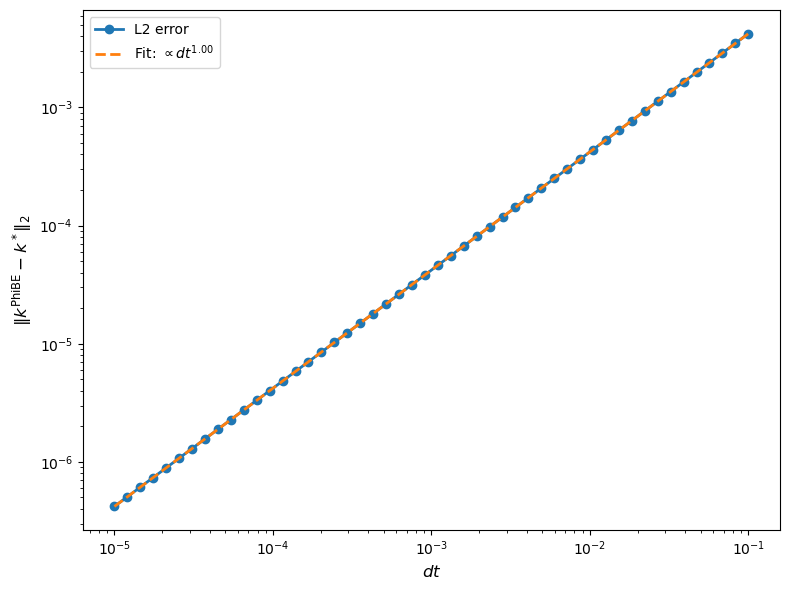

In [25]:
df_plot = df_compare_k[(df_compare_k["dt"] > 0) & (df_compare_k["k_error_l2"] > 0)].copy()

x = df_plot["dt"].values
y = df_plot["k_error_l2"].values

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)
y_fit = np.exp(intercept) * x**slope

print(f"Estimated log-log slope = {slope:.6f}")

plt.figure(figsize=(8, 6))
plt.loglog(x, y, marker="o", linewidth=2, label="L2 error")
plt.loglog(x, y_fit, "--", linewidth=2, label=rf"Fit: $\propto dt^{{{slope:.2f}}}$")
plt.xlabel(r"$dt$", fontsize=12)
plt.ylabel(r"$\|k^{\mathrm{PhiBE}}-k^*\|_2$", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()